In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder

### Gaussian NB

In [6]:
gaussian_df_noShale = pd.read_csv("data/nb/gnb_data.csv")

# Train test splitting
Training_G, Testing_G = train_test_split(gaussian_df_noShale, test_size=.2)

Training_G_Label = Training_G["LITHOLOGY"]
Training_G=Training_G.drop(["LITHOLOGY"], axis=1)

Testing_G_Label = Testing_G["LITHOLOGY"]
Testing_G = Testing_G.drop(["LITHOLOGY"], axis=1)

display(Training_G.head(3))
display(Testing_G_Label.head(3))

,CALI,RHOB,NPHI,DTC
12154,8.354388,2.764160,0.266902,61.165169
1170,11.743252,2.550217,0.156392,61.445637
13518,11.148439,2.332126,0.191998,87.064606


10984    Sandstone
8362     Sandstone
13417    Sandstone
Name: LITHOLOGY, dtype: object

In [7]:
# Fitting
from sklearn.naive_bayes import GaussianNB
# Create Gaussian Naive Bayes model
MyGNB = GaussianNB()
# Fit the model on the training data
MyGNB_Model = MyGNB.fit(Training_G, Training_G_Label)

# Predict the Testing Data using the model
Predictions_G = MyGNB_Model.predict(Testing_G)
print(Predictions_G[:5])

['Sandstone' 'Sandstone' 'Limestone' 'Sandstone' 'Chalk']


In [8]:
## Print the probabilities
## Recall that Naive Bayes calculates the probability of each label even though it only predicts the largest of those probabilities.
## Knowing the probabilities of each label will help you to see how "certain" (or not) the model was about its prediction.
print("The Gaussian NB Model Prediction Probabilities are:")
print(MyGNB_Model.predict_proba(Testing_G).round(3))

The Gaussian NB Model Prediction Probabilities are:
[[0.    0.001 0.    ... 0.695 0.16  0.   ]
 [0.    0.004 0.    ... 0.806 0.136 0.011]
 [0.214 0.    0.    ... 0.139 0.106 0.   ]
 ...
 [0.    0.    0.    ... 0.576 0.297 0.   ]
 [0.062 0.    0.    ... 0.185 0.158 0.   ]
 [0.042 0.    0.    ... 0.134 0.113 0.   ]]


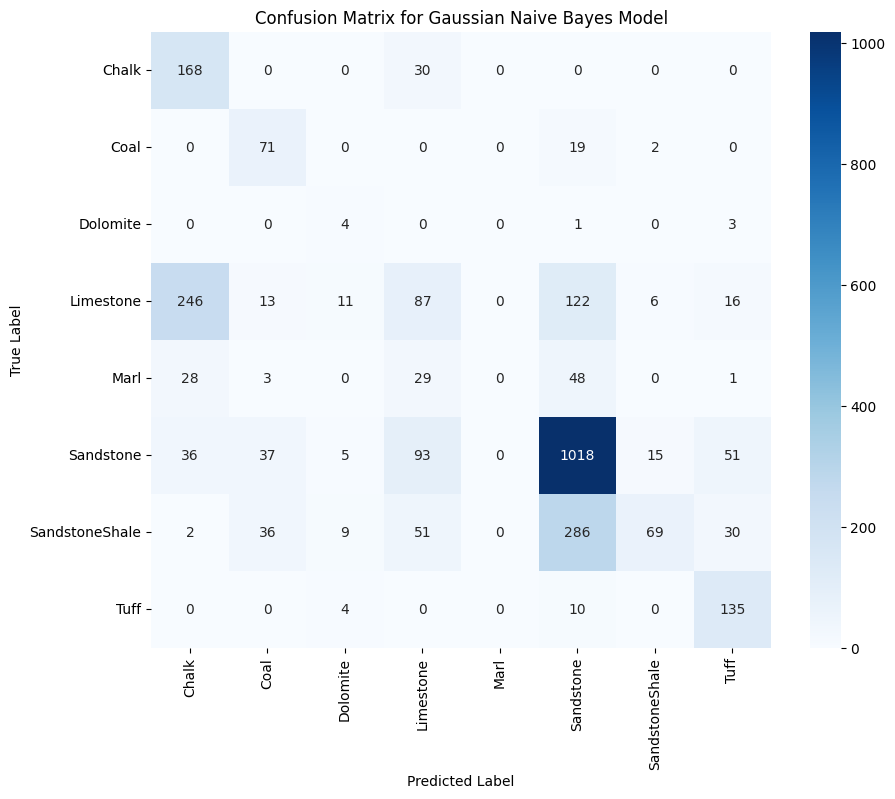

In [9]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Create confusion matrix
cm = confusion_matrix(Testing_G_Label, Predictions_G, labels=MyGNB_Model.classes_)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=MyGNB_Model.classes_,
            yticklabels=MyGNB_Model.classes_)
plt.title('Confusion Matrix for Gaussian Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Categorical NB

In [10]:
categorical_df = pd.read_csv("data/nb/cnb_data.csv")

Training_C, Testing_C = train_test_split(categorical_df, test_size=.2)

# Train test splitting
Training_C_Label = Training_C["LITHOLOGY"]
Training_C=Training_C.drop(["LITHOLOGY"], axis=1)
Testing_C_Label = Testing_C["LITHOLOGY"]
Testing_C=Testing_C.drop(["LITHOLOGY"], axis=1)

display(Testing_C.head(3))
Testing_C_Label.head(3)

,CALI,RHOB,NPHI,DTC
3255,0.0,1.0,0.0,1.0
9750,0.0,1.0,0.0,1.0
6959,0.0,2.0,0.0,1.0


3255         Sandstone
9750         Sandstone
6959    SandstoneShale
Name: LITHOLOGY, dtype: object

In [11]:
from sklearn.naive_bayes import CategoricalNB

MyCNB = CategoricalNB()

# Fit the model
My_CNB_Model = MyCNB.fit(Training_C, Training_C_Label)

# Predict the Testing Data using the model
Predictions_C=My_CNB_Model.predict(Testing_C)
print("First 5 predicted values: ", Predictions_C[:5])

# Print the actual probabilities
print("\nThe Categorical NB Model Prediction Probabilities are:")
print(My_CNB_Model.predict_proba(Testing_C).round(3))

First 5 predicted values:  ['Sandstone' 'Sandstone' 'SandstoneShale' 'Sandstone' 'Sandstone']

The Categorical NB Model Prediction Probabilities are:
[[0.    0.002 0.    ... 0.676 0.285 0.   ]
 [0.    0.002 0.    ... 0.676 0.285 0.   ]
 [0.004 0.001 0.    ... 0.322 0.387 0.   ]
 ...
 [0.    0.113 0.195 ... 0.248 0.019 0.409]
 [0.    0.002 0.    ... 0.676 0.285 0.   ]
 [0.004 0.001 0.    ... 0.322 0.387 0.   ]]


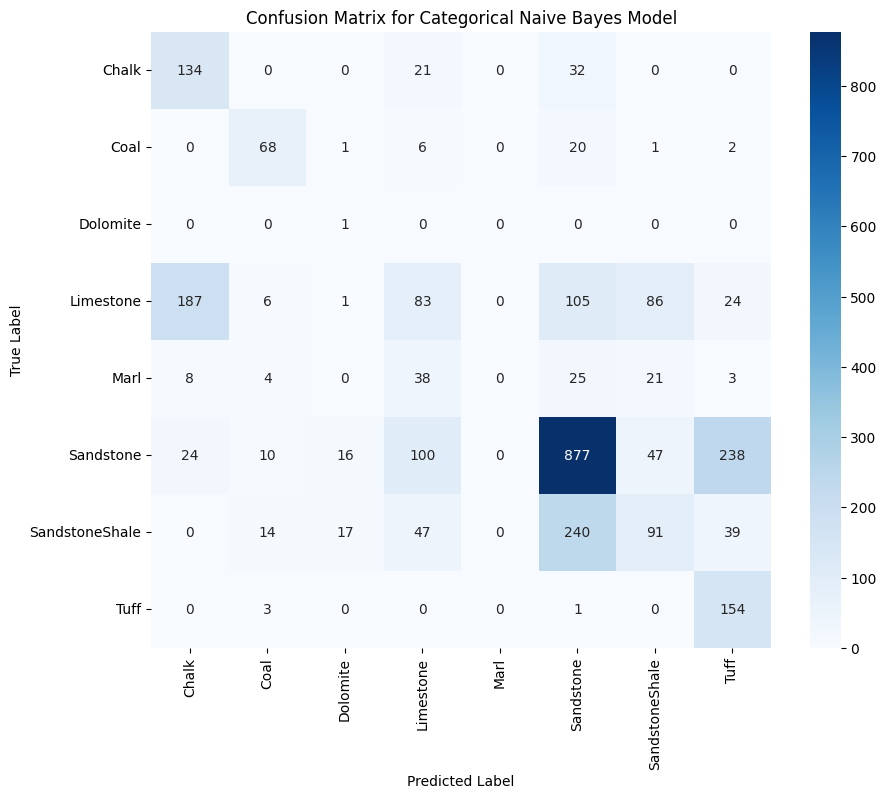

In [12]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Create confusion matrix
cm = confusion_matrix(Testing_C_Label, Predictions_C, labels=My_CNB_Model.classes_)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=My_CNB_Model.classes_,
            yticklabels=My_CNB_Model.classes_)
plt.title('Confusion Matrix for Categorical Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Multinomial NB

In [14]:
multinomial_df = pd.read_csv("data/nb/mnb_data.csv")

multinomial_df = categorical_df.copy()
# Train test splitting
Training_MN, Testing_MN = train_test_split(multinomial_df, test_size=.2)
##  Save the Labels and then remove them from the Training and Testing data
Training_MN_Label = Training_MN["LITHOLOGY"]
Training_MN=Training_MN.drop(["LITHOLOGY"], axis=1)
Testing_MN_Label = Testing_MN["LITHOLOGY"]
Testing_MN=Testing_MN.drop(["LITHOLOGY"], axis=1)

display(Testing_MN.head(3))
Testing_MN_Label.head(3)

,CALI,RHOB,NPHI,DTC
4229,0.0,1.0,0.0,1.0
3550,0.0,1.0,0.0,1.0
6455,0.0,0.0,1.0,1.0


4229         Sandstone
3550    SandstoneShale
6455              Coal
Name: LITHOLOGY, dtype: object

In [15]:
from sklearn.naive_bayes import MultinomialNB

MyMN = MultinomialNB()
display(Training_MN.head(3))
display(Training_MN_Label.head(3))
## Traing the model
My_MN_Model = MyMN.fit(Training_MN, Training_MN_Label)
print(My_MN_Model)
print(My_MN_Model.classes_)

## Predict the Testing Data using the model
Predictions_MN=My_MN_Model.predict(Testing_MN)
print(Predictions_MN)

## Print the actual probabilities
print("\n\nThe Multinomial NB Model Prediction Probabilities are:")
print(My_MN_Model.predict_proba(Testing_MN).round(3))

,CALI,RHOB,NPHI,DTC
4377,0.0,1.0,0.0,1.0
7935,1.0,1.0,1.0,1.0
4892,0.0,1.0,0.0,1.0


4377         Sandstone
7935              Tuff
4892    SandstoneShale
Name: LITHOLOGY, dtype: object

MultinomialNB()
['Chalk' 'Coal' 'Dolomite' 'Limestone' 'Marl' 'Sandstone' 'SandstoneShale'
 'Tuff']
['Sandstone' 'Sandstone' 'Sandstone' ... 'Sandstone' 'Sandstone'
 'Sandstone']


The Multinomial NB Model Prediction Probabilities are:
[[0.007 0.012 0.001 ... 0.541 0.252 0.024]
 [0.007 0.012 0.001 ... 0.541 0.252 0.024]
 [0.    0.165 0.006 ... 0.459 0.198 0.12 ]
 ...
 [0.007 0.012 0.001 ... 0.541 0.252 0.024]
 [0.    0.064 0.007 ... 0.565 0.127 0.126]
 [0.007 0.012 0.001 ... 0.541 0.252 0.024]]


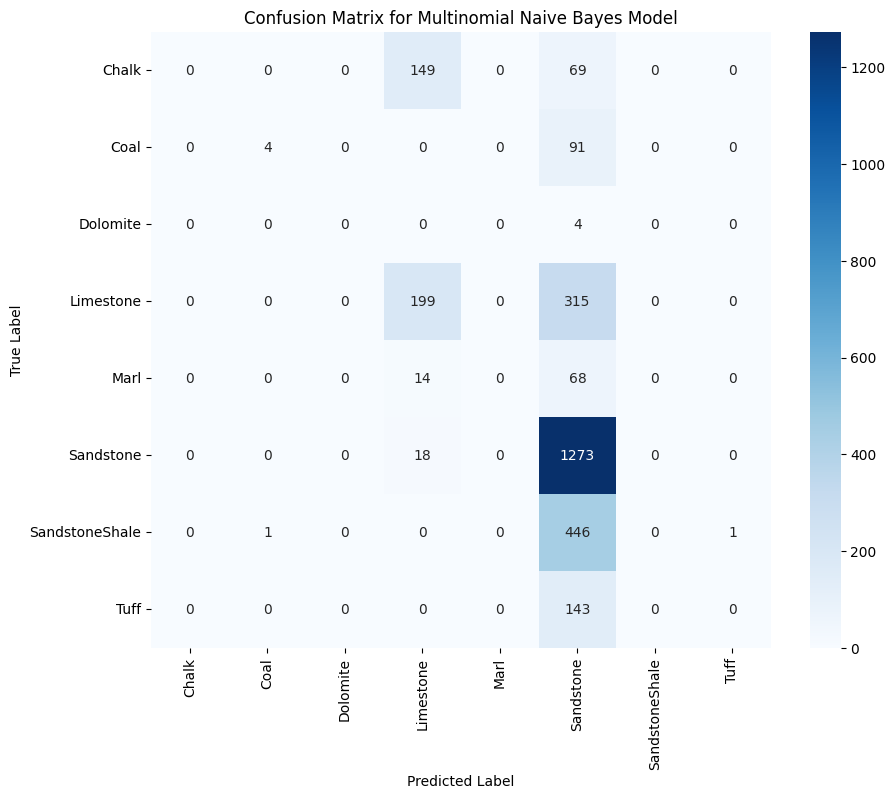

In [16]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Create confusion matrix
cm = confusion_matrix(Testing_MN_Label, Predictions_MN, labels=My_MN_Model.classes_)
# Plotting the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=My_MN_Model.classes_,
            yticklabels=My_MN_Model.classes_)
plt.title('Confusion Matrix for Multinomial Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Evaluation

In [17]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report, confusion_matrix
import numpy as np

def evaluate_multiclass_model(y_true, y_pred, y_proba, average='weighted'):
    """
    Evaluate a multi-class classification model with imbalanced data.
    
    Parameters:
    - y_true : array-like, true class labels
    - y_pred : array-like, predicted class labels
    - y_proba: array-like, predicted probability for each class
    - average: str, averaging method for multi-class metrics ('macro', 'micro', 'weighted')

    Returns:
    - A dictionary containing accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC scores.
    """
    metrics = {}

    # Accuracy
    metrics["Accuracy"] = accuracy_score(y_true, y_pred)

    # Precision, Recall, F1-Score
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=average)
    metrics["Precision"] = precision
    metrics["Recall"] = recall
    metrics["F1-Score"] = f1

    # ROC-AUC Score (only works if y_proba is available)
    try:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba, multi_class="ovr", average=average)
    except:
        metrics["ROC-AUC"] = "N/A (Check y_proba format)"

    # Print classification report
    print("Classification Report:\n", classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

    return metrics

##### Gaussian NV model evaluation

In [18]:
g_results = evaluate_multiclass_model(Testing_G_Label, Predictions_G, MyGNB_Model.predict_proba(Testing_G))


Classification Report:
                 precision    recall  f1-score   support

         Chalk       0.35      0.85      0.50       198
          Coal       0.44      0.77      0.56        92
      Dolomite       0.12      0.50      0.20         8
     Limestone       0.30      0.17      0.22       501
          Marl       0.00      0.00      0.00       109
     Sandstone       0.68      0.81      0.74      1255
SandstoneShale       0.75      0.14      0.24       483
          Tuff       0.57      0.91      0.70       149

      accuracy                           0.56      2795
     macro avg       0.40      0.52      0.39      2795
  weighted avg       0.56      0.56      0.50      2795

Confusion Matrix:
 [[ 168    0    0   30    0    0    0    0]
 [   0   71    0    0    0   19    2    0]
 [   0    0    4    0    0    1    0    3]
 [ 246   13   11   87    0  122    6   16]
 [  28    3    0   29    0   48    0    1]
 [  36   37    5   93    0 1018   15   51]
 [   2   36    9   51   

/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

##### Categorical NB model evaluation

In [19]:
c_results = evaluate_multiclass_model(Testing_C_Label, Predictions_C, MyCNB.predict_proba(Testing_C))

Classification Report:
                 precision    recall  f1-score   support

         Chalk       0.38      0.72      0.50       187
          Coal       0.65      0.69      0.67        98
      Dolomite       0.03      1.00      0.05         1
     Limestone       0.28      0.17      0.21       492
          Marl       0.00      0.00      0.00        99
     Sandstone       0.67      0.67      0.67      1312
SandstoneShale       0.37      0.20      0.26       448
          Tuff       0.33      0.97      0.50       158

      accuracy                           0.50      2795
     macro avg       0.34      0.55      0.36      2795
  weighted avg       0.49      0.50      0.48      2795

Confusion Matrix:
 [[134   0   0  21   0  32   0   0]
 [  0  68   1   6   0  20   1   2]
 [  0   0   1   0   0   0   0   0]
 [187   6   1  83   0 105  86  24]
 [  8   4   0  38   0  25  21   3]
 [ 24  10  16 100   0 877  47 238]
 [  0  14  17  47   0 240  91  39]
 [  0   3   0   0   0   1   0 154]]


/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

##### Multinomial NB model evaluation

In [20]:
# Multinomial NB model evaluation
mn_results = evaluate_multiclass_model(
    y_true=Testing_MN_Label,
    y_pred=Predictions_MN,
    y_proba=My_MN_Model.predict_proba(Testing_MN),
    average='weighted'
)
print(mn_results)

Classification Report:
                 precision    recall  f1-score   support

         Chalk       0.00      0.00      0.00       218
          Coal       0.80      0.04      0.08        95
      Dolomite       0.00      0.00      0.00         4
     Limestone       0.52      0.39      0.45       514
          Marl       0.00      0.00      0.00        82
     Sandstone       0.53      0.99      0.69      1291
SandstoneShale       0.00      0.00      0.00       448
          Tuff       0.00      0.00      0.00       143

      accuracy                           0.53      2795
     macro avg       0.23      0.18      0.15      2795
  weighted avg       0.37      0.53      0.40      2795

Confusion Matrix:
 [[   0    0    0  149    0   69    0    0]
 [   0    4    0    0    0   91    0    0]
 [   0    0    0    0    0    4    0    0]
 [   0    0    0  199    0  315    0    0]
 [   0    0    0   14    0   68    0    0]
 [   0    0    0   18    0 1273    0    0]
 [   0    1    0    0   

/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/dna-tuananguyen/anaconda3/envs/booksage/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av